# Inter-Rater Reliability Analysis — Rayyan Screening Log

**Project**: Building Standards for Agent-Based Models (scoping review, 2015–2025)
**Purpose**: Quantify the agreement between the independent reviewers who screened titles/abstracts in Rayyan, and document the consensus mechanism used to resolve disagreements.

---

## What this notebook does (and does *not* do)

This is a **reproduction artifact**. It reports the agreement statistics for screening decisions that *were already made* by the human reviewers. It does **not** automate, replace, or relitigate the consensus process — those decisions remain the authoritative record.

**Reports**:
1. Reviewer activity profile (decisions per reviewer, overlap structure)
2. Pairwise Cohen's κ for every reviewer pair with overlapping articles
3. Krippendorff's α across all reviewers (handles unequal overlap)
4. Percent agreement and confusion matrices per pair
5. Conflict resolution analysis (how disagreements were settled)
6. A publication-ready text snippet for the response letter

**Does not report**:
- Per-reviewer "accuracy" (no ground truth exists; the consensus *is* the truth)
- Imputed values for non-overlapping decisions
- Any inference about reviewer "quality"

---

## Inputs

Place the Rayyan export `customizations_log.csv` in the same directory as this notebook, or update `CSV_PATH` in the configuration cell.

Expected schema (Rayyan v2 export, as of 2025):

| Column        | Type   | Notes                                          |
|---------------|--------|------------------------------------------------|
| `user_email`  | string | Identifies the reviewer                        |
| `article_id`  | int    | Rayyan internal article ID                     |
| `key`         | string | Type of decision (`"included"` for screening)  |
| `value`       | int    | `-1` = exclude, `0` = maybe, `1` = include     |

If your columns differ, adjust the `COLUMN_MAP` in the configuration cell.


## 1. Setup

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import krippendorff
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")

print("Setup OK.")

Setup OK.


### 1.1 Configuration — edit paths and identities here only

In [26]:
# --- File path -----------------------------------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

DATA_PATH = Path(PROJECT_ROOT) / "data" / "customizations_log.csv"
df = pd.read_csv(DATA_PATH)

# --- Column mapping ------------------------------------------------------
# Map Rayyan column names to internal names used by this notebook.
# Adjust ONLY if your CSV has different column names.
COLUMN_MAP = {
    "user_email": "reviewer",
    "article_id": "article_id",
    "key":        "decision_type",
    "value":      "decision",
}

# --- Reviewer identity normalisation -------------------------------------
# Rayyan stores user_email; map each email to a short display name.
# Add or edit as needed.
REVIEWER_NAMES = {
    "thiago.rossi@usp.br": "Thiago",
    "ms7murilo@gmail.com": "Murilo",
    "ceciliaklapka@usp.br": "Cecilia",
}

# --- Decision encoding (Rayyan default) ---------------------------------
DECISION_LABELS = {-1: "exclude", 0: "maybe", 1: "include"}
DECISION_ORDER  = [-1, 0, 1]

# --- Primary pair --------------------------------------------------------
# The two reviewers whose agreement is the headline number for the paper.
# Leave as None to auto-detect (the two reviewers with the highest volume).
PRIMARY_PAIR = None    # e.g. ("Thiago", "Murilo")

# --- Output --------------------------------------------------------------
OUTPUT_DIR = Path("interrater_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"CSV path: {DATA_PATH.resolve()}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")

CSV path: C:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\data\customizations_log.csv
Output dir: C:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\notebooks\interrater_outputs


## 2. Load and inspect

We load the CSV and run a few sanity checks before computing anything.

In [27]:
assert DATA_PATH.exists(), f"File not found: {DATA_PATH.resolve()}"

raw = pd.read_csv(DATA_PATH)
print(f"Rows in raw export: {len(raw):,}")
print(f"Columns: {list(raw.columns)}")
raw.head()

Rows in raw export: 3,407
Columns: ['created_at', 'user_id', 'user_email', 'article_id', 'key', 'value']


,created_at,user_id,user_email,article_id,key,value
0,2026-02-18T21:41:09.021Z,532162,thiago.rossi@usp.br,448617523,included,1
1,2026-02-18T21:41:36.754Z,532162,thiago.rossi@usp.br,448617524,included,1
2,2026-02-18T21:42:56.581Z,532162,thiago.rossi@usp.br,448617529,included,-1
3,2026-02-18T21:43:18.759Z,532162,thiago.rossi@usp.br,448617531,included,-1
4,2026-02-18T21:43:39.114Z,532162,thiago.rossi@usp.br,448617532,included,-1


In [28]:
# Apply column mapping
missing = [c for c in COLUMN_MAP if c not in raw.columns]
assert not missing, f"Expected columns not found in CSV: {missing}"

df = raw.rename(columns=COLUMN_MAP)[list(COLUMN_MAP.values())].copy()

# Apply reviewer name mapping (falls back to the raw email/username)
df["reviewer"] = df["reviewer"].map(REVIEWER_NAMES).fillna(df["reviewer"])

# Keep only inclusion/exclusion decisions (Rayyan also logs labels, exclusion-reason
# customizations, etc. under different `key` values).
inclusion_keys = df["decision_type"].value_counts()
print("Decision types found in the log:")
print(inclusion_keys.to_string())
print()

screening = df[df["decision_type"] == "included"].copy()
screening["decision"] = pd.to_numeric(screening["decision"], errors="coerce").astype("Int64")
screening = screening.dropna(subset=["decision"])
screening["decision"] = screening["decision"].astype(int)

print(f"Screening decisions retained: {len(screening):,}")
print(f"Unique reviewers: {screening['reviewer'].nunique()}")
print(f"Unique articles: {screening['article_id'].nunique():,}")

Decision types found in the log:
decision_type
included    3407

Screening decisions retained: 3,407
Unique reviewers: 3
Unique articles: 1,472


In [29]:
# Per-reviewer profile: counts and decision distribution
profile = (
    screening
    .assign(decision_label=lambda d: d["decision"].map(DECISION_LABELS))
    .groupby(["reviewer", "decision_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[DECISION_LABELS[v] for v in DECISION_ORDER], fill_value=0)
)
profile["total"] = profile.sum(axis=1)
profile = profile.sort_values("total", ascending=False)
profile

decision_label,exclude,maybe,include,total
reviewer,,,,
Thiago,1112,46,358,1516
Murilo,898,2,604,1504
Cecilia,218,52,117,387


## 3. Reviewer overlap structure

Each article was screened by one, two, or three reviewers. Kappa requires *paired* decisions, so we need to know exactly which articles were independently re-screened, by whom.

In [30]:
# Some reviewers may have changed their mind and logged multiple decisions for the
# same article. We keep the LAST decision per (reviewer, article) pair, which matches
# Rayyan's effective screening state.
screening_sorted = screening.sort_index()    # original log order; last row wins
wide = (
    screening_sorted
    .drop_duplicates(subset=["reviewer", "article_id"], keep="last")
    .pivot(index="article_id", columns="reviewer", values="decision")
)
print(f"Articles in wide matrix: {len(wide):,}")
print(f"Reviewer columns: {list(wide.columns)}\n")

n_reviewers_per_article = wide.notna().sum(axis=1)
overlap_counts = n_reviewers_per_article.value_counts().sort_index()
overlap_counts.index.name = "reviewers_per_article"
overlap_counts.name = "n_articles"
overlap_counts.to_frame()

Articles in wide matrix: 1,472
Reviewer columns: ['Cecilia', 'Murilo', 'Thiago']



,n_articles
reviewers_per_article,
2,1100
3,372


In [31]:
# Pairwise overlap matrix: for each pair of reviewers, how many articles do both rated?
reviewers = sorted(wide.columns)
overlap_mat = pd.DataFrame(0, index=reviewers, columns=reviewers, dtype=int)
for a, b in combinations(reviewers, 2):
    n = wide[[a, b]].dropna().shape[0]
    overlap_mat.loc[a, b] = overlap_mat.loc[b, a] = n
for r in reviewers:
    overlap_mat.loc[r, r] = wide[r].notna().sum()
overlap_mat

,Cecilia,Murilo,Thiago
Cecilia,372,372,372
Murilo,372,1472,1472
Thiago,372,1472,1472


In [32]:
# Auto-detect primary pair if not specified: two reviewers with most overlap
if PRIMARY_PAIR is None:
    candidates = []
    for a, b in combinations(reviewers, 2):
        candidates.append(((a, b), overlap_mat.loc[a, b]))
    candidates.sort(key=lambda x: -x[1])
    PRIMARY_PAIR = candidates[0][0]
    print(f"Auto-detected primary pair: {PRIMARY_PAIR} (n={candidates[0][1]:,} overlapping articles)")
else:
    n = overlap_mat.loc[PRIMARY_PAIR[0], PRIMARY_PAIR[1]]
    print(f"Primary pair: {PRIMARY_PAIR} (n={n:,} overlapping articles)")

Auto-detected primary pair: ('Murilo', 'Thiago') (n=1,472 overlapping articles)


## 4. Pairwise Cohen's κ

For each pair of reviewers with overlapping articles, we compute three quantities:

- **Percent agreement** (raw, no chance correction)
- **Cohen's κ** treating decisions as **nominal** categories
- **Linear-weighted Cohen's κ** treating decisions as **ordinal** (`exclude < maybe < include`)

The ordinal/weighted version is the more defensible single number, because confusing *include* with *exclude* is a worse disagreement than confusing *include* with *maybe*.

Interpretation (Landis & Koch, 1977):

| κ           | Strength of agreement |
|-------------|-----------------------|
| < 0.00      | Poor                  |
| 0.00–0.20   | Slight                |
| 0.21–0.40   | Fair                  |
| 0.41–0.60   | Moderate              |
| 0.61–0.80   | Substantial           |
| 0.81–1.00   | Almost perfect        |


In [33]:
def pairwise_metrics(wide_df, r1, r2):
    paired = wide_df[[r1, r2]].dropna()
    n = len(paired)
    if n == 0:
        return None
    x, y = paired[r1].astype(int).values, paired[r2].astype(int).values
    return {
        "reviewer_a":        r1,
        "reviewer_b":        r2,
        "n_overlap":         n,
        "percent_agreement": (x == y).mean(),
        "kappa_nominal":     cohen_kappa_score(x, y, labels=DECISION_ORDER),
        "kappa_linear":      cohen_kappa_score(x, y, labels=DECISION_ORDER, weights="linear"),
        "kappa_quadratic":   cohen_kappa_score(x, y, labels=DECISION_ORDER, weights="quadratic"),
    }

pair_rows = [pairwise_metrics(wide, a, b) for a, b in combinations(reviewers, 2)]
pair_rows = [r for r in pair_rows if r is not None]
pairwise_df = pd.DataFrame(pair_rows)
pairwise_df = pairwise_df.sort_values("n_overlap", ascending=False).reset_index(drop=True)
pairwise_df.round(3)

,reviewer_a,reviewer_b,n_overlap,percent_agreement,kappa_nominal,kappa_linear,kappa_quadratic
0,Murilo,Thiago,1472,0.732,0.424,0.439,0.447
1,Cecilia,Murilo,372,0.608,0.301,0.340,0.363
2,Cecilia,Thiago,372,0.645,0.337,0.405,0.449


In [34]:
# Headline: primary pair, linear-weighted kappa
a, b = PRIMARY_PAIR
primary_row = pairwise_df.query("reviewer_a in @PRIMARY_PAIR and reviewer_b in @PRIMARY_PAIR").iloc[0]

print(f"=== PRIMARY PAIR: {a} × {b} ===")
print(f"  Overlapping articles:   {primary_row['n_overlap']:,}")
print(f"  Percent agreement:      {primary_row['percent_agreement']:.1%}")
print(f"  Cohen's κ (nominal):    {primary_row['kappa_nominal']:.3f}")
print(f"  Cohen's κ (linear):     {primary_row['kappa_linear']:.3f}  ← headline")
print(f"  Cohen's κ (quadratic):  {primary_row['kappa_quadratic']:.3f}")

=== PRIMARY PAIR: Murilo × Thiago ===
  Overlapping articles:   1,472
  Percent agreement:      73.2%
  Cohen's κ (nominal):    0.424
  Cohen's κ (linear):     0.439  ← headline
  Cohen's κ (quadratic):  0.447


## 5. Confusion matrices

These show *where* disagreements happen — the kappa number alone hides whether the disagreements were soft (include vs. maybe) or hard (include vs. exclude).

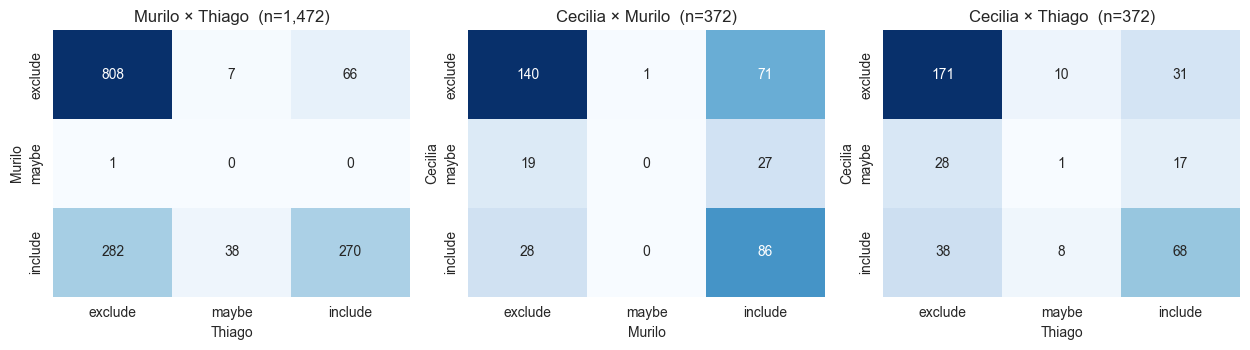

In [35]:
def plot_confusion(wide_df, r1, r2, ax=None):
    paired = wide_df[[r1, r2]].dropna().astype(int)
    cm = confusion_matrix(paired[r1], paired[r2], labels=DECISION_ORDER)
    labels = [DECISION_LABELS[v] for v in DECISION_ORDER]
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, cbar=False, ax=ax
    )
    ax.set_xlabel(r2); ax.set_ylabel(r1)
    ax.set_title(f"{r1} × {r2}  (n={paired.shape[0]:,})")
    return ax

n_pairs = len(pairwise_df)
fig, axes = plt.subplots(1, n_pairs, figsize=(4.2 * n_pairs, 3.6))
if n_pairs == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, pairwise_df.iterrows()):
    plot_confusion(wide, row["reviewer_a"], row["reviewer_b"], ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Krippendorff's α — overall reliability across all reviewers

Cohen's κ is pairwise. When you have more than two raters and unequal overlap (most articles screened by 2 reviewers, some by 3), Krippendorff's α is the standard summary statistic. It handles missing values natively.

We compute both:
- **Nominal α** — treats decisions as unordered categories
- **Ordinal α** — treats `exclude < maybe < include` as an ordered scale (preferred)

Conventional thresholds: α ≥ 0.80 is considered reliable for tentative conclusions; α ≥ 0.667 is the minimum often cited (Krippendorff, 2004).

In [36]:
# krippendorff expects a 2D array: rows = raters, columns = items
alpha_matrix = wide[reviewers].T.values.astype(float)   # NaN preserved

alpha_nominal = krippendorff.alpha(
    reliability_data=alpha_matrix, level_of_measurement="nominal"
)
alpha_ordinal = krippendorff.alpha(
    reliability_data=alpha_matrix, level_of_measurement="ordinal"
)
print(f"Krippendorff's α (nominal): {alpha_nominal:.3f}")
print(f"Krippendorff's α (ordinal): {alpha_ordinal:.3f}  ← headline\n")

if alpha_ordinal >= 0.80:
    interp = "reliable for definitive conclusions"
elif alpha_ordinal >= 0.667:
    interp = "acceptable for tentative conclusions"
else:
    interp = "below conventional reliability threshold — consensus mechanism essential"
print(f"Interpretation: {interp}")

Krippendorff's α (nominal): 0.400
Krippendorff's α (ordinal): 0.447  ← headline

Interpretation: below conventional reliability threshold — consensus mechanism essential


## 7. Conflict resolution — how disagreements were settled

Inter-rater reliability is one half of the story. The other half is the *consensus mechanism* that turned disagreements into final decisions. This section quantifies it.

We define three severities of disagreement on the primary pair:

- **Hard conflict**: one reviewer said *include*, the other said *exclude* (–1 vs. +1)
- **Soft conflict**: one said *maybe*, the other said *include* or *exclude* (0 vs. ±1)
- **Agreement**: identical decision

For each disagreement, we check whether a third reviewer also recorded a decision on that article — and which way that decision went.

In [37]:
a, b = PRIMARY_PAIR
others = [r for r in reviewers if r not in PRIMARY_PAIR]

paired = wide[[a, b]].dropna().astype(int).copy()

def classify(row):
    da, db = row[a], row[b]
    if da == db:
        return "agreement"
    if abs(da - db) == 2:
        return "hard_conflict"
    return "soft_conflict"

paired["status"] = paired.apply(classify, axis=1)

status_counts = paired["status"].value_counts().reindex(
    ["agreement", "soft_conflict", "hard_conflict"], fill_value=0
)
status_pct = (status_counts / status_counts.sum() * 100).round(1)
pd.DataFrame({"n": status_counts, "%": status_pct})

,n,%
status,,
agreement,1078,73.2
soft_conflict,46,3.1
hard_conflict,348,23.6


In [38]:
# For conflicts, did a third reviewer weigh in?
conflicts = paired[paired["status"] != "agreement"].copy()
print(f"Total conflicts on primary pair: {len(conflicts):,}")

if others:
    third = others[0] if len(others) == 1 else None
    if third is None:
        # Multiple third reviewers: combine non-null
        conflicts["third_decision"] = wide.loc[conflicts.index, others].bfill(axis=1).iloc[:, 0]
    else:
        conflicts["third_decision"] = wide.loc[conflicts.index, third]

    resolved = conflicts["third_decision"].notna()
    print(f"  Conflicts with a third-reviewer decision: {resolved.sum():,} ({resolved.mean():.1%})")
    print(f"  Conflicts resolved by discussion only (no third-reviewer log): {(~resolved).sum():,}")
    print()

    if resolved.any():
        print("Third-reviewer decisions on conflicts:")
        labels = conflicts.loc[resolved, "third_decision"].astype(int).map(DECISION_LABELS)
        print(labels.value_counts().to_string())
else:
    print("  (Only two reviewers in the dataset; no third-reviewer resolution to analyse.)")

Total conflicts on primary pair: 394
  Conflicts with a third-reviewer decision: 137 (34.8%)
  Conflicts resolved by discussion only (no third-reviewer log): 257

Third-reviewer decisions on conflicts:
third_decision
include    60
exclude    59
maybe      18


## 8. Export results

In [39]:
# Save key tables for audit / supplementary material
profile.to_csv(OUTPUT_DIR / "reviewer_profile.csv")
overlap_mat.to_csv(OUTPUT_DIR / "overlap_matrix.csv")
pairwise_df.round(4).to_csv(OUTPUT_DIR / "pairwise_agreement.csv", index=False)

summary = {
    "n_reviewers":            len(reviewers),
    "n_articles_screened":    int(wide.shape[0]),
    "n_screening_decisions":  int(len(screening)),
    "primary_pair":           list(PRIMARY_PAIR),
    "primary_n_overlap":      int(primary_row["n_overlap"]),
    "primary_percent_agreement":  float(round(primary_row["percent_agreement"], 4)),
    "primary_kappa_nominal":  float(round(primary_row["kappa_nominal"], 4)),
    "primary_kappa_linear":   float(round(primary_row["kappa_linear"], 4)),
    "krippendorff_alpha_nominal": float(round(alpha_nominal, 4)),
    "krippendorff_alpha_ordinal": float(round(alpha_ordinal, 4)),
}
import json
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2))
print("Saved to", OUTPUT_DIR.resolve())
summary

Saved to C:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\notebooks\interrater_outputs


{'n_reviewers': 3,
 'n_articles_screened': 1472,
 'n_screening_decisions': 3407,
 'primary_pair': ['Murilo', 'Thiago'],
 'primary_n_overlap': 1472,
 'primary_percent_agreement': 0.7323,
 'primary_kappa_nominal': 0.4243,
 'primary_kappa_linear': 0.439,
 'krippendorff_alpha_nominal': 0.4004,
 'krippendorff_alpha_ordinal': 0.4472}